In [ ]:
#Câu 23.1
import folium
m=folium.Map(location=[10.772, 106.698],zoom_start=15)
group_landmarks = folium.FeatureGroup(name='Địa điểm tham quan').add_to(m)
folium.Marker([10.772, 106.698], popup='Chợ Bến Thành', tooltip='Click vào').add_to(group_landmarks)
folium.Marker([10.776, 106.703], popup='Nhà hát thành phố', tooltip='Click vào').add_to(group_landmarks)
folium.Marker([10.779556722123726, 106.69913606174521], popup='Nhà thờ Đức Bà', tooltip='Click vào').add_to(group_landmarks)
folium.Marker([10.77159535981354, 106.7042543969926], popup='Tòa nhà Bitexco', tooltip='Click vào').add_to(group_landmarks)
folium.Marker([10.768971277324844, 106.69239026043874], popup='Công viên 23 tháng 9', tooltip='Click vào').add_to(group_landmarks)
folium.LayerControl().add_to(m)
m

In [ ]:
#Câu 23.2
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time
location = ('Chợ Lớn, Thành phố Hồ Chí Minh', 'Chợ Quán, Thành phố Hồ Chí Minh','Xóm Chiếu, Thành phố Hồ Chí Minh','Bàn Cờ, Thành phố Hồ Chí Minh','Minh Phụng, Thành phố Hồ Chí Minh','Vĩnh Hội, Thành phố Hồ Chí Minh','Hòa Bình, Thành phố Hồ Chí Minh','An Đông, Thành phố Hồ Chí Minh','Bình Hưng, Thành phố Hồ Chí Minh','Bình Tây, Thành phố Hồ Chí Minh')
center_address=('Bến Thành, Thành phố Hồ Chí Minh')
geolocator = Nominatim(user_agent="geo_exercise")
center_loc = geolocator.geocode(center_address)
center_coords = (center_loc.latitude, center_loc.longitude)
data_point=[]
for i in location:
  add=geolocator.geocode(i)
  if add:
    coords= (add.latitude, add.longitude)
    distance = geodesic(coords,center_coords ).km
    data_point.append({"name": i, "coords": coords, "distance": distance})
    time.sleep(1)
m=folium.Map(location=center_coords,zoom_start=15)
folium.Marker(center_coords, popup='Trung tâm').add_to(m)
for j in data_point:
  folium.Marker(j['coords'], popup=f"{j['name']}:{j['distance']:.2f}km").add_to(m)
  folium.PolyLine([center_coords, j['coords']], color="blue", weight=2, opacity=0.5).add_to(m)
m

In [ ]:
#Câu 23.3
import folium
from folium.plugins import HeatMap
from branca.element import Template, MacroElement
m = folium.Map(location=[10.775, 106.700], zoom_start=15)
heat_data=([10.774, 106.691], [10.775, 106.695], [10.775,106.7],[10.764,106.696],[10.764,106.705])
HeatMap(heat_data, radius=30, blur=20).add_to(m)
template = """
{% macro html(this, kwargs) %}
<div style="
    position: fixed;
    bottom: 50px; left: 50px; width: 300px; height: 250px;
    background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
    padding: 10px; border-radius: 10px; opacity: 0.9;
    ">
    <center><b>CHÚ GIẢI QUẢN TRỊ</b></center>
    <hr style="margin: 5px 0;">
    <i style="background:red; width:15px; height:15px; float:left; margin-right:8px; border-radius:50%;"></i>
    <b>Vùng Nóng:</b> Vùng có lượng khách hàng cao, nên có thêm cửa hàng mới <br><br>
    <i style="background:yellow; width:15px; height:15px; float:left; margin-right:8px; border-radius:50%;"></i>
    <b>Vùng Ấm:</b> Tiềm năng, có lượng khách hàng sẵn sàng trung bình, cần đầu tư thêm <br><br>
    <i style="background:cyan; width:15px; height:15px; float:left; margin-right:8px; border-radius:50%;"></i>
    <b>Vùng Lạnh:</b> Lượng khách hàng thấp, không cần đầu tư quá nhiều để tối ưu chi phí
</div>
{% endmacro %}
"""
macro = MacroElement()
macro._template = Template(template)
m.get_root().add_child(macro)
m

In [ ]:
#Câu 23.5
import folium
m=folium.Map(location=[10.772, 106.698],zoom_start=12)
service_areas = [
    {"name": "Nội thành", "radius": 3000, "color": "red", "fill": True, "desc": "Giao hàng hỏa tốc < 30p; Đề xuất: Sử dụng xe máy, xe đạp điện để tối ưu tốc độ và len lỏi ngõ ngách."},
    {"name": "Ven đô", "radius": 5000, "color": "cyan", "fill": True, "desc": "Giao hàng trong ngày; Đề xuất:Gom đơn theo tuyến để tối ưu chi phí"},
    {"name": "Ngoại ô", "radius": 10000, "color": "black", "fill": True, "desc": "Vùng chịu phí ship cao; Đề xuất: Áp dụng phụ phí vận chuyển hoặc trạm vệ tinh"}
]
for area in reversed(service_areas):
    folium.Circle(
        location=[10.772, 106.698],
        radius=area["radius"],
        color=area["color"],
        weight=2,
        fill=area["fill"],
        fill_opacity=0.2,
        popup=f"{area['name']}: {area['desc']}"
    ).add_to(m)
folium.Marker([10.772, 106.698], popup='HUB').add_to(m)
m

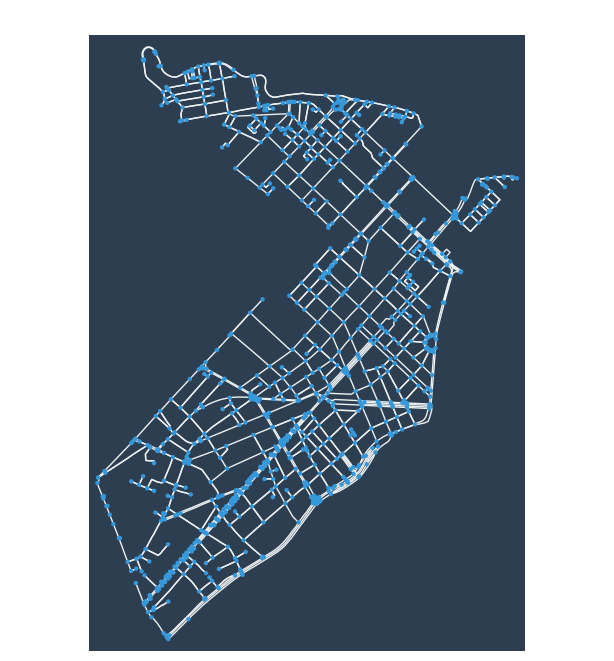

--- THÔNG SỐ MẠNG LƯỚI ---
Số lượng nút giao (Intersections): 985
Số lượng đoạn đường (Edges): 2081
Chiều dài đường trung bình: 79.30 mét
# VAI TRÒ CỦA DỮ LIỆU MẠNG GIAO THÔNG TRONG AI ĐÔ THỊ THÔNG MINH
-Giúp tối ưu hóa lộ trình thời gian thực, từ đó giảm chi phí vận chuyển
-Mô phỏng tác động của các tác nhân như ngập lụt, tắc đường,...
-Giúp cho việc quy hoạch cơ sở hạ tầng, phục vụ dân sinh tốt hơn
-Là nền tảng giúp xe tự hành hiểu được cấu trúc hình học của các nút giao và quy tắc ưu tiên tại các luồng rẽ


In [ ]:
#Câu 23.6
import osmnx as ox
import matplotlib.pyplot as plt
place_name = "Quận 1, Ho Chi Minh City, Vietnam"
graph = ox.graph_from_place(place_name, network_type='drive')
stats = ox.basic_stats(graph)
fig, ax = ox.plot_graph(graph, node_size=10, node_color='#3498db',
                        edge_color='#ecf0f1', bgcolor='#2c3e50',
                        show=False, close=False)
ax.set_title(f"Mạng lưới giao thông: {place_name}", color='white', fontsize=15)
plt.show()
print(f"--- THÔNG SỐ MẠNG LƯỚI ---")
print(f"Số lượng nút giao (Intersections): {stats['n']}")
print(f"Số lượng đoạn đường (Edges): {stats['m']}")
print(f"Chiều dài đường trung bình: {stats['edge_length_avg']:.2f} mét")
print(f'# VAI TRÒ CỦA DỮ LIỆU MẠNG GIAO THÔNG TRONG AI ĐÔ THỊ THÔNG MINH')
print(f'-Giúp tối ưu hóa lộ trình thời gian thực, từ đó giảm chi phí vận chuyển')
print(f'-Mô phỏng tác động của các tác nhân như ngập lụt, tắc đường,...')
print(f'-Giúp cho việc quy hoạch cơ sở hạ tầng, phục vụ dân sinh tốt hơn')
print(f'-Là nền tảng giúp xe tự hành hiểu được cấu trúc hình học của các nút giao và quy tắc ưu tiên tại các luồng rẽ')

Nhập Vĩ độ điểm đi: 10.772
Nhập Kinh độ điểm đi: 106.698
Nhập Vĩ độ điểm đến: 10.77
Nhập Kinh độ điểm đến: 106.697


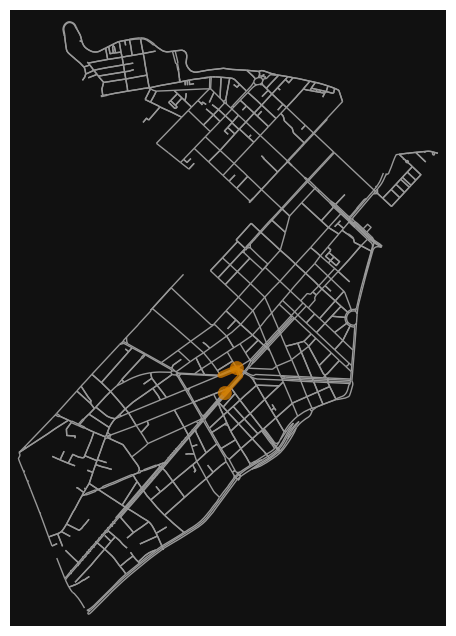


--- SO SÁNH ---
Dijkstra: 0.000351 giây
A*:       0.000765 giây
Độ dài quãng đường: 537.56 mét
# So sánh 2 cách
- A*:
+ ƯU: Nhanh hơn rất nhiều trong các bản đồ đô thị lớn nhờ giảm số nút phải kiểm tra.
+ NHƯỢC: Phụ thuộc vào hàm Heuristic. Nếu hàm này sai, đường đi tìm được có thể không ngắn nhất.
- Dijkstra:
+ ƯU: Đảm bảo luôn tìm được đường ngắn nhất tuyệt đối trên mọi đồ thị.
+ NHƯỢC: Lãng phí tài nguyên máy tính vì kiểm tra cả những vùng đi ngược hướng đích.


In [155]:
#Câu 23.7
import osmnx as ox
import networkx as nx
import time
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
lat1 = float(input("Nhập Vĩ độ điểm đi: "))
lon1 = float(input("Nhập Kinh độ điểm đi: "))
lat2 = float(input("Nhập Vĩ độ điểm đến: "))
lon2 = float(input("Nhập Kinh độ điểm đến: "))
start_node = ox.nearest_nodes(G, lon1, lat1)
end_node = ox.nearest_nodes(G, lon2, lat2)
start_time = time.time()
path_dijkstra = nx.shortest_path(G, start_node, end_node, weight='length', method='dijkstra')
dijkstra_time = time.time() - start_time
def heuristic(u, v):
    coords_u = (G.nodes[u]['y'], G.nodes[u]['x'])
    coords_v = (G.nodes[v]['y'], G.nodes[v]['x'])
    return ox.distance.great_circle(coords_u[0], coords_u[1], coords_v[0], coords_v[1])
start_time = time.time()
path_astar = nx.astar_path(G, start_node, end_node, heuristic=heuristic, weight='length')
astar_time = time.time() - start_time
fig, ax = ox.plot_graph_routes(G, [path_dijkstra, path_astar],
                                   route_colors=['r', 'y'], route_linewidth=4, node_size=0)
print(f"\n--- SO SÁNH ---")
print(f"Dijkstra: {dijkstra_time:.6f} giây")
print(f"A*:       {astar_time:.6f} giây")
print(f"Độ dài quãng đường: {nx.path_weight(G, path_dijkstra, weight='length'):.2f} mét")

print(f'# So sánh 2 cách')
print(f'- A*:')
print(f'+ ƯU: Nhanh hơn rất nhiều trong các bản đồ đô thị lớn nhờ giảm số nút phải kiểm tra.')
print(f'+ NHƯỢC: Phụ thuộc vào hàm Heuristic. Nếu hàm này sai, đường đi tìm được có thể không ngắn nhất.')
print(f'- Dijkstra:')
print(f'+ ƯU: Đảm bảo luôn tìm được đường ngắn nhất tuyệt đối trên mọi đồ thị.')
print(f'+ NHƯỢC: Lãng phí tài nguyên máy tính vì kiểm tra cả những vùng đi ngược hướng đích.')


In [129]:
#Câu 23.8
import osmnx as ox
import networkx as nx
import folium
import numpy as np
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
np.random.seed(42)

passengers = [
    {"id": "P1", "pickup": (10.772, 106.698), "dropoff": (10.776, 106.701)},
    {"id": "P2", "pickup": (10.775, 106.693), "dropoff": (10.779, 106.696)}]
drivers = [
    {"id": "D1", "coords": (10.770, 106.700), "occupied": False},
    {"id": "D2", "coords": (10.778, 106.690), "occupied": False},
    {"id": "D3", "coords": (10.776, 106.697), "occupied": False}]

for p in passengers:
    p['pickup_node'] = ox.nearest_nodes(G, p['pickup'][1], p['pickup'][0])
    p['dropoff_node'] = ox.nearest_nodes(G, p['dropoff'][1], p['dropoff'][0])
for d in drivers:
    d['node'] = ox.nearest_nodes(G, d['coords'][1], d['coords'][0])

matches = []
for p in passengers:
    min_dist = float('inf')
    best_driver = None
    for d in drivers:
        if not d['occupied']:
            try:
                dist = nx.shortest_path_length(G, d['node'], p['pickup_node'], weight='length')
                if dist < min_dist:
                    min_dist = dist
                    best_driver = d
            except nx.NetworkXNoPath: continue

    if best_driver:
        best_driver['occupied'] = True
        matches.append({"passenger": p, "driver": best_driver})

m = folium.Map(location=[10.776, 106.696], zoom_start=15, tiles='cartodbpositron')

folium.GeoJson(
    edges_gdf[['geometry']],
    style_function=lambda x: {'color': '#cccccc', 'weight': 0.5, 'opacity': 0.5}
).add_to(m)

def draw_route(m, G, route, color):
    route_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route]
    folium.PolyLine(route_coords, color=color, weight=4, opacity=0.8).add_to(m)

for match in matches:
    p, d = match['passenger'], match['driver']
    folium.Marker(d['coords'], icon=folium.Icon(color='orange', icon='car', prefix='fa')).add_to(m)
    folium.Marker(p['pickup'], icon=folium.Icon(color='blue', icon='user', prefix='fa')).add_to(m)
    folium.Marker(p['dropoff'], icon=folium.Icon(color='red', icon='flag', prefix='fa')).add_to(m)
    try:
        route_to_pickup = nx.shortest_path(G, d['node'], p['pickup_node'], weight='length')
        draw_route(m, G, route_to_pickup, 'orange')
        route_to_dropoff = nx.shortest_path(G, p['pickup_node'], p['dropoff_node'], weight='length')
        draw_route(m, G, route_to_dropoff, 'blue')
    except: pass
m

In [142]:
#Câu 23.9
import folium
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
np.random.seed(42)
customers_1 = np.random.normal(loc=[10.776, 106.701], scale=0.015, size=(100, 2))
customers_2 = np.random.normal(loc=[10.732, 106.714], scale=0.015, size=(80, 2))
customers_3 = np.random.normal(loc=[10.801, 106.654], scale=0.015, size=(70, 2))
X = np.vstack((customers_1, customers_2, customers_3))
df_customers = pd.DataFrame(X, columns=['Latitude', 'Longitude'])
K=2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_customers['Cluster'] = kmeans.fit_predict(X)
hubs = kmeans.cluster_centers_
m = folium.Map(location=[10.776, 106.680], zoom_start=12)
colors = ['#3498db', '#e74c3c', '#2ecc71']
for _, row in df_customers.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2,
        color=colors[int(row['Cluster'])],
        fill=True,
        fill_opacity=0.6
    ).add_to(m)
for i, hub in enumerate(hubs):
    folium.Marker(
        location=[hub[0], hub[1]],
        icon=folium.Icon(color='black', icon='home', prefix='fa'),
        popup=f'<b>Trạm Trung Chuyển Tối Ưu {i+1}</b><br>Phục vụ Cụm {i+1}',
        tooltip='Click xem chi tiết'
    ).add_to(m)
    folium.Circle(
        location=[hub[0], hub[1]],
        radius=5000,
        color=colors[i],
        weight=2,
        fill=False
    ).add_to(m)
m

/usr/local/lib/python3.12/dist-packages/osmnx/_overpass.py:271: UserWarning: This area is 22 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


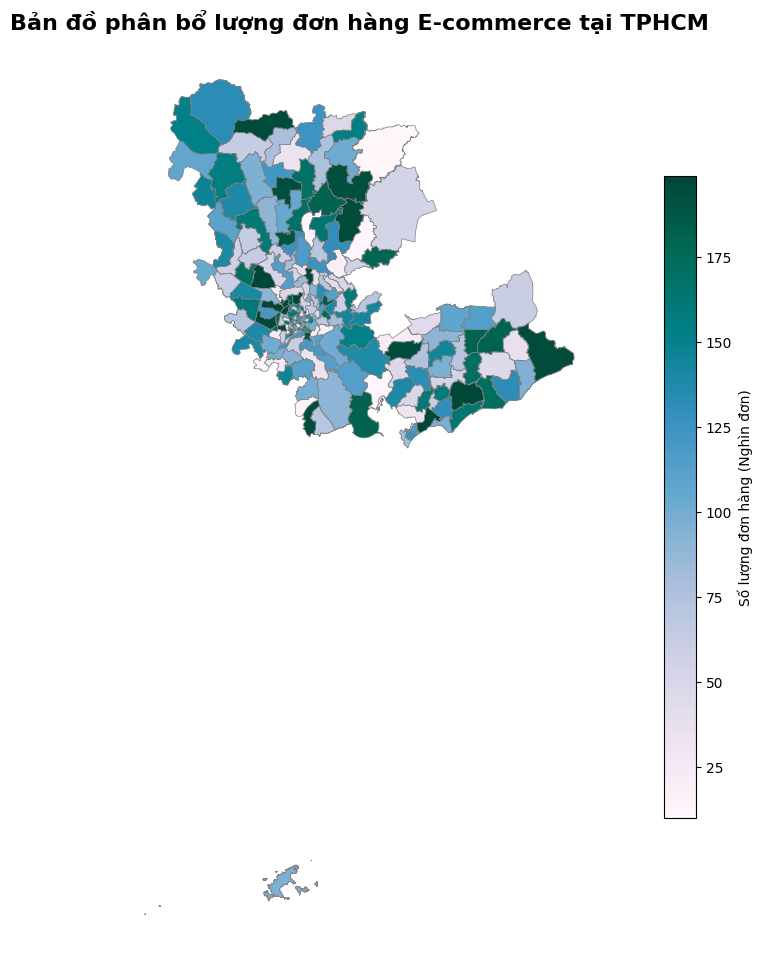

In [144]:
#Câu 23.4
import osmnx as ox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
tags = {'admin_level': '6'}
gdf_hcmc_districts = ox.features_from_place("Ho Chi Minh City, Vietnam", tags=tags)
gdf_hcmc_districts = gdf_hcmc_districts[gdf_hcmc_districts.geometry.type.isin(['Polygon', 'MultiPolygon'])]
districts = gdf_hcmc_districts['name'].dropna().tolist()
np.random.seed(42)
base_orders = np.random.randint(10, 200, size=len(districts))
df_data = pd.DataFrame({'name': districts, 'orders_k': base_orders})
merged_gdf = gdf_hcmc_districts.merge(df_data, on='name')
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
merged_gdf.plot(column='orders_k',
                ax=ax,
                legend=True,
                cmap='PuBuGn',
                legend_kwds={'label': "Số lượng đơn hàng (Nghìn đơn)",
                             'orientation': "vertical",
                             'shrink': 0.7},
                edgecolor='gray',
                linewidth=0.5)
plt.title('Bản đồ phân bổ lượng đơn hàng E-commerce tại TPHCM', fontsize=16, fontweight='bold')
plt.tight_layout()
ax.set_axis_off()
plt.show()

In [146]:
#Câu 23.10
import osmnx as ox
import networkx as nx
import folium
import pandas as pd
import numpy as np
from branca.element import Template, MacroElement
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
np.random.seed(42)
for u, v, k, data in G.edges(data=True, keys=True):
    density = np.random.rand()
    lanes = int(data.get('lanes', 2) if isinstance(data.get('lanes'), str) else 2)
    risk_score = density * (1 / (lanes * 0.5))
    data['congestion_risk'] = min(risk_score, 1.0)
    data['weighted_cost'] = data['length'] * (1 + data['congestion_risk'] * 5)
start_coords = (10.772, 106.698)
end_coords = (10.759008223992485, 106.68700941660472)
start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])
route_shortest = nx.shortest_path(G, start_node, end_node, weight='length')
route_ai = nx.shortest_path(G, start_node, end_node, weight='weighted_cost')
m = folium.Map(location=[10.776, 106.701], zoom_start=15, tiles='cartodbpositron')
for u, v, k, data in G.edges(data=True, keys=True):
    if data['congestion_risk'] > 0.7:
        mid_lat = (G.nodes[u]['y'] + G.nodes[v]['y']) / 2
        mid_lon = (G.nodes[u]['x'] + G.nodes[v]['x']) / 2
        folium.Circle([mid_lat, mid_lon], radius=15, color='red', fill=True, opacity=0.3).add_to(m)

def add_route(m, G, route, color, label):
    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(coords, color=color, weight=5, opacity=0.8, popup=label).add_to(m)

add_route(m, G, route_shortest, 'black', 'Đường ngắn nhất (Có thể tắc)')
add_route(m, G, route_ai, 'green', 'Đường AI đề xuất (Thông thoáng hơn)')
template = """
{% macro html(this, kwargs) %}
<div style="
    position: fixed;
    bottom: 20px; left: 20px; width: 300px; height: 90px;
    background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
    padding: 10px; border-radius: 10px; opacity: 0.9;
    ">
    <center><b>CHÚ GIẢI</b></center>
    <hr style="margin: 5px 0;">
    <i style="background:red; width:15px; height:15px; float:left; margin-right:8px; border-radius:50%;"></i>
    <b>Vòng tròn:</b> ứng với 1 phương tiện <br><br>
</div>
{% endmacro %}
"""
macro = MacroElement()
macro._template = Template(template)
m.get_root().add_child(macro)
m

In [148]:
#Câu 23.11
print(f'PHÂN TÍCH SỰ KHÁC BIỆT KHU VỰC')
print(f'Quận 1 và 3 cũ: nhu cầu thường rất cao vào đầu giờ sáng, và cuối buổi chiều, vì tập trung các khu thương mại và văn phòng')
print(f'Quận 7 và Thủ Đức cũ: luôn có 2 đỉnh, sáng sẽ sớm hơn ở quận 1 và 3; còn chiều sẽ muộn hơn 1 chút')
print(f'Tân Bình cũ: do có sân bay nên nhu cầu nhìn chung khá đều giữa các thời điểm')
print(f'--------------')
print(f'Ý NGHĨA TRONG ĐIỀU PHỐI NGUỒN LỰC')
print(f'Phục vụ việc nhân giá linh hoạt')
print(f'Chống lãng phí km chạy rỗng')
print(f'Quản lý ca làm việc của nhân viên, tăng hiệu quả quản lý')
print(f'--------------')

import pandas as pd
import numpy as np
import folium
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
hcm_districts = {
    'Quận 1 cũ': (10.776, 106.701),
    'Quận 3 cũ': (10.783, 106.680),
    'Quận 7 cũ': (10.732, 106.714),
    'Tân Bình cũ': (10.801, 106.654),
    'Thủ Đức cũ': (10.850, 106.758)
}
np.random.seed(40)
data = []
for district in hcm_districts.keys():
    for hour in range(24):
        for day in range(30):
            is_weekend = 1 if day % 7 >= 5 else 0
            base_demand = np.random.randint(10, 50)
            if district in ['Quận 1 cũ', 'Quận 3 cũ'] and (8 <= hour <= 18):
                base_demand += np.random.randint(50, 150)
            if district in ['Quận 7 cũ', 'Thủ Đức cũ'] and (hour in [7, 8, 17, 18]):
                base_demand += np.random.randint(80, 200)
            if district == 'Tân Bình cũ' and (6 <= hour <= 22):
                base_demand += np.random.randint(40, 100)

            data.append([district, hour, is_weekend, base_demand])

df = pd.DataFrame(data, columns=['District', 'Hour', 'Is_Weekend', 'Demand'])
le = LabelEncoder()
df['District_Encoded'] = le.fit_transform(df['District'])

X = df[['District_Encoded', 'Hour', 'Is_Weekend']]
y = df['Demand']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)
target_hour = float(input('NHẬP GIỜ DỰ ĐOÁN:'))
target_weekend = float(input('nhập ngày:'))

predictions = {}
for district in hcm_districts.keys():
    dist_encoded = le.transform([district])[0]
    pred = model.predict([[dist_encoded, target_hour, target_weekend]])[0]
    predictions[district] = pred

m = folium.Map(location=[10.790, 106.700], zoom_start=12, tiles='cartodbpositron')

print(f"\n--- KẾT QUẢ DỰ ĐOÁN SỐ CUỐC XE LÚC {target_hour}:00 ---")
for dist, coords in hcm_districts.items():
    predicted_demand = predictions[dist]
    print(f"{dist}: ~{int(predicted_demand)} yêu cầu")

    radius_size = predicted_demand / 10
    color = 'red' if predicted_demand > 150 else ('orange' if predicted_demand > 80 else 'green')

    folium.CircleMarker(
        location=coords,
        radius=radius_size,
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=f"<b>{dist}</b><br>Dự báo: {int(predicted_demand)} cuốc xe"
    ).add_to(m)
m



PHÂN TÍCH SỰ KHÁC BIỆT KHU VỰC
Quận 1 và 3 cũ: nhu cầu thường rất cao vào đầu giờ sáng, và cuối buổi chiều, vì tập trung các khu thương mại và văn phòng
Quận 7 và Thủ Đức cũ: luôn có 2 đỉnh, sáng sẽ sớm hơn ở quận 1 và 3; còn chiều sẽ muộn hơn 1 chút
Tân Bình cũ: do có sân bay nên nhu cầu nhìn chung khá đều giữa các thời điểm
--------------
Ý NGHĨA TRONG ĐIỀU PHỐI NGUỒN LỰC
Phục vụ việc nhân giá linh hoạt
Chống lãng phí km chạy rỗng
Quản lý ca làm việc của nhân viên, tăng hiệu quả quản lý
--------------
NHẬP GIỜ DỰ ĐOÁN:20
nhập ngày:12


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(



--- KẾT QUẢ DỰ ĐOÁN SỐ CUỐC XE LÚC 20.0:00 ---
Quận 1 cũ: ~29 yêu cầu
Quận 3 cũ: ~33 yêu cầu
Quận 7 cũ: ~27 yêu cầu
Tân Bình cũ: ~86 yêu cầu
Thủ Đức cũ: ~32 yêu cầu


In [151]:
#Câu 23.12
import osmnx as ox
import networkx as nx
import folium
import numpy as np

place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')

depots = [
    {'id': 'Kho A', 'coords': (10.772, 106.698), 'color': 'darkblue'},
    {'id': 'Kho B', 'coords': (10.785, 106.700), 'color': 'darkred'}
]
deliveries = [
    {'id': 'P1', 'coords': (10.776, 106.701)},
    {'id': 'P3', 'coords': (10.771, 106.692)}, {'id': 'P4', 'coords': (10.782, 106.705)},
    {'id': 'P5', 'coords': (10.788, 106.698)}
]

for d in depots: d['node'] = ox.nearest_nodes(G, d['coords'][1], d['coords'][0])
for p in deliveries: p['node'] = ox.nearest_nodes(G, p['coords'][1], p['coords'][0])

def get_route_dist(node1, node2):
    try:
        dist_meters = nx.shortest_path_length(G, node1, node2, weight='length')
        return dist_meters / 1000
    except nx.NetworkXNoPath:
        return float('inf')

naive_route_nodes = [depots[0]['node']] + [p['node'] for p in deliveries] + [depots[0]['node']]
naive_total_km = 0
for i in range(len(naive_route_nodes)-1):
    naive_total_km += get_route_dist(naive_route_nodes[i], naive_route_nodes[i+1])

clusters = {d['id']: [] for d in depots}
for p in deliveries:
    best_depot = min(depots, key=lambda d: get_route_dist(d['node'], p['node']))
    clusters[best_depot['id']].append(p)

optimized_total_km = 0
routes_to_draw = []

for depot in depots:
    current_node = depot['node']
    unvisited = clusters[depot['id']].copy()

    while unvisited:
        next_point = min(unvisited, key=lambda p: get_route_dist(current_node, p['node']))
        dist = get_route_dist(current_node, next_point['node'])

        optimized_total_km += dist
        routes_to_draw.append(nx.shortest_path(G, current_node, next_point['node'], weight='length'))

        current_node = next_point['node']
        unvisited.remove(next_point)

    optimized_total_km += get_route_dist(current_node, depot['node'])
    routes_to_draw.append(nx.shortest_path(G, current_node, depot['node'], weight='length'))

print(f"\n--- ĐÁNH GIÁ HIỆU QUẢ ---")
print(f"Tổng quãng đường (Không tối ưu): {naive_total_km:.2f} km")
print(f"Tổng quãng đường (Có tối ưu): {optimized_total_km:.2f} km")
print(f"-> Tiết kiệm được: {naive_total_km - optimized_total_km:.2f} km")

def draw_route(m, G, route, color, weight=4):
    try:

        route_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route]
        folium.PolyLine(route_coords, color=color, weight=weight, opacity=0.8).add_to(m)
    except Exception as e:
        pass

m = folium.Map(location=[10.778, 106.698], zoom_start=14, tiles='cartodbpositron')

for p in deliveries:
    folium.Marker(
        p['coords'],
        popup=f"Điểm giao {p['id']}",
        icon=folium.Icon(color='lightgray', icon='box', prefix='fa')
    ).add_to(m)

for d in depots:
    folium.Marker(
        d['coords'],
        popup=f"<b>{d['id']}</b>",
        icon=folium.Icon(color=d['color'], icon='home', prefix='fa')
    ).add_to(m)

for depot in depots:
    current_node = depot['node']
    unvisited = clusters[depot['id']].copy()

    while unvisited:
        next_point = min(unvisited, key=lambda p: get_route_dist(current_node, p['node']))

        try:
            route = nx.shortest_path(G, current_node, next_point['node'], weight='length')
            draw_route(m, G, route, color=depot['color'])
        except nx.NetworkXNoPath:
            pass

        current_node = next_point['node']
        unvisited.remove(next_point)

    try:
        route_back = nx.shortest_path(G, current_node, depot['node'], weight='length')
        route_coords_back = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route_back]
        folium.PolyLine(
            route_coords_back,
            color=depot['color'],
            weight=3,
            opacity=0.6,
            dash_array='5, 10'
        ).add_to(m)
    except nx.NetworkXNoPath:
        pass

legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; width: 220px; height: 130px;
     border:2px solid grey; z-index:9999; font-size:14px; background-color:white; padding:10px;">
     <b>CHÚ GIẢI TUYẾN ĐƯỜNG</b><br>
     <i style="background:darkblue; width:15px; height:3px; float:left; margin-top:8px; margin-right:5px;"></i> Xe Kho A (Có hàng)<br><br>
     <i style="background:darkred; width:15px; height:3px; float:left; margin-top:8px; margin-right:5px;"></i> Xe Kho B (Có hàng)<br><br>
     <i style="border-top: 3px dashed gray; width:15px; float:left; margin-top:8px; margin-right:5px;"></i> Xe quay về (Không tải)
</div>
'''
m.get_root().add_child(folium.Element(legend_html))

m


--- ĐÁNH GIÁ HIỆU QUẢ ---
Tổng quãng đường (Không tối ưu): 9.26 km
Tổng quãng đường (Có tối ưu): 7.34 km
-> Tiết kiệm được: 1.92 km


In [161]:
#Câu 23.13
import osmnx as ox
import networkx as nx
import folium
from folium import plugins

place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')

depot = {'id': 'Kho Trung Tâm', 'coords': (10.772, 106.698)}
stores = [
    {'id': 'Cửa hàng A', 'coords': (10.785, 106.700)},
    {'id': 'Cửa hàng B', 'coords': (10.771, 106.692)},
]

depot['node'] = ox.nearest_nodes(G, depot['coords'][1], depot['coords'][0])
for s in stores:
    s['node'] = ox.nearest_nodes(G, s['coords'][1], s['coords'][0])

m = folium.Map(location=[10.776, 106.695], zoom_start=14, tiles='cartodbpositron')

layer_polygons = folium.FeatureGroup(name='1. Vùng: Vành đai phục vụ (3km)', show=True)
layer_points = folium.FeatureGroup(name='2. Điểm: Hệ thống Kho & Cửa hàng', show=True)
layer_routes = folium.FeatureGroup(name='3. Tuyến: Đường vận chuyển thực tế', show=False)

folium.Circle(
    location=depot['coords'], radius=3000,
    color='blue', weight=1, fill=True, fill_opacity=0.1,
    popup="Vùng phục vụ tiêu chuẩn (3km)"
).add_to(layer_polygons)

folium.Marker(
    depot['coords'],
    popup=f"<b>{depot['id']}</b>",
    icon=folium.Icon(color='red', icon='home', prefix='fa')
).add_to(layer_points)

for s in stores:
    folium.Marker(
        s['coords'],
        popup=f"<b>{s['id']}</b><br>Tình trạng: Cần nhập hàng",
        icon=folium.Icon(color='green', icon='shopping-cart', prefix='fa')
    ).add_to(layer_points)

for s in stores:
    try:
        route = nx.shortest_path(G, depot['node'], s['node'], weight='length')
        dist_km = nx.shortest_path_length(G, depot['node'], s['node'], weight='length') / 1000

        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]

        folium.PolyLine(
            route_coords,
            color='purple', weight=4, opacity=0.8,
            popup=f"Tuyến Kho -> {s['id']}<br>Cự ly thực: {dist_km:.2f} km"
        ).add_to(layer_routes)
    except nx.NetworkXNoPath:
        pass

layer_polygons.add_to(m)
layer_points.add_to(m)
layer_routes.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

plugins.MiniMap(toggle_display=True).add_to(m)

m

In [170]:
import osmnx as ox
import networkx as nx
import folium
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')

vehicles = [
    {"id": "Xe 01", "color": "#FF0000", "start": (10.772, 106.698), "end": (10.785, 106.700)},
    {"id": "Xe 02", "color": "#0000FF", "start": (10.775, 106.690), "end": (10.778, 106.705)},
    {"id": "Xe 03", "color": "#008000", "start": (10.780, 106.695), "end": (10.771, 106.692)}
]

start_time = datetime(2024, 1, 1, 8, 0, 0)
speed_kmh = 30
speed_ms = speed_kmh / 3.6

features = []

for v in vehicles:
    start_node = ox.nearest_nodes(G, v["start"][1], v["start"][0])
    end_node = ox.nearest_nodes(G, v["end"][1], v["end"][0])

    try:
        path = nx.shortest_path(G, start_node, end_node, weight='length')

        coords = []
        times = []
        current_time = start_time

        for i, node in enumerate(path):
            lon = G.nodes[node]['x']
            lat = G.nodes[node]['y']
            coords.append([lon, lat])
            times.append(current_time.strftime("%Y-%m-%dT%H:%M:%S"))

            if i < len(path) - 1:
                next_node = path[i+1]
                edge_data = G.get_edge_data(node, next_node)
                length = edge_data[0].get('length', 50) if edge_data else 50
                seconds = int(length / speed_ms)
                current_time += timedelta(seconds=seconds)

        feature = {
            "type": "Feature",
            "geometry": {
                "type": "LineString",
                "coordinates": coords
            },
            "properties": {
                "times": times,
                "style": {"color": v["color"], "weight": 5},
                "icon": "circle",
                "popup": f"<b>{v['id']}</b>"
            }
        }
        features.append(feature)

    except nx.NetworkXNoPath:
        print(f"Không tìm thấy đường cho {v['id']}")

m = folium.Map(location=[10.776, 106.695], zoom_start=14, tiles='cartodbpositron')

TimestampedGeoJson(
    {"type": "FeatureCollection", "features": features},
    period='PT15S',
    add_last_point=True,
    auto_play=False,
    loop=False,
    max_speed=2,
    loop_button=True,
    date_options='HH:mm:ss',
    time_slider_drag_update=True
).add_to(m)

m

In [11]:
#Câu 23.15
import numpy as np
import pandas as pd
import folium
from sklearn.cluster import KMeans
import random

np.random.seed(42)
demand_core = np.random.normal(loc=[10.776, 106.701], scale=0.015, size=(300, 2))
demand_east = np.random.normal(loc=[10.795, 106.735], scale=0.02, size=(200, 2))
demand_south = np.random.normal(loc=[10.732, 106.714], scale=0.018, size=(150, 2))

X_demand = np.vstack((demand_core, demand_east, demand_south))
df_demand = pd.DataFrame(X_demand, columns=['Lat', 'Lon'])

num_stations = 5

kmeans = KMeans(n_clusters=num_stations, random_state=42, n_init=10)
df_demand['Cluster'] = kmeans.fit_predict(X_demand)
optimal_stations = kmeans.cluster_centers_

m = folium.Map(location=[10.760, 106.715], zoom_start=13, tiles='cartodbpositron')

colors = [f"#{random.randint(0, 0xFFFFFF):06x}" for _ in range(num_stations)]

for _, row in df_demand.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=2,
        color=colors[int(row['Cluster'])],
        fill=True,
        opacity=0.4
    ).add_to(m)

for i, station in enumerate(optimal_stations):
    folium.Marker(
        location=[station[0], station[1]],
        popup=f"<b>Trạm sạc chiến lược #{i+1}</b><br>Phục vụ vùng {i}",
        icon=folium.Icon(color='red', icon='bolt', prefix='fa')
    ).add_to(m)

    folium.Circle(
        location=[station[0], station[1]],
        radius=1500,
        color='red',
        weight=2,
        fill=False,
        dash_array='5, 5'
    ).add_to(m)

m